# Assignment 7: Text Preprocessing and Analysis using NLTK
## Tokenization, POS Tagging, and Basic NLP Tasks

This notebook implements a comprehensive text preprocessing and analysis pipeline using NLTK.

### Topics Covered:
1. Text Preprocessing (cleaning, normalization)
2. Tokenization (word and sentence)
3. Stop Word Removal
4. Stemming and Lemmatization
5. Part-of-Speech (POS) Tagging
6. Named Entity Recognition (NER)
7. Frequency Distribution Analysis
8. N-Gram Analysis
9. Full Preprocessing Pipeline

## 1. Install and Import Libraries

In [1]:
!pip install nltk matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import nltk
import string
import re
from collections import Counter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Download all required NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.tokenize import word_tokenize, sent_tokenize, TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag, ne_chunk
from nltk.probability import FreqDist
from nltk.util import ngrams

print("All libraries imported successfully!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Us

All libraries imported successfully!


[nltk_data]   Package omw-1.4 is already up-to-date!


## 2. Sample Text for Analysis

In [2]:
# Sample paragraph for NLP analysis
sample_text = """
Natural Language Processing (NLP) is a subfield of artificial intelligence and linguistics.
It focuses on the interactions between computers and human language.
NLP enables machines to read, understand, and derive meaning from human language.
Applications include machine translation, sentiment analysis, and speech recognition.
Google, Amazon, and Microsoft are leading companies investing heavily in NLP research.
The field has seen remarkable progress due to deep learning and transformer architectures.
Models like BERT, GPT, and T5 have revolutionized the way we process text data.
Researchers are working hard to make these models faster, smaller, and more efficient.
"""

print("Sample Text:")
print("=" * 60)
print(sample_text)

Sample Text:

Natural Language Processing (NLP) is a subfield of artificial intelligence and linguistics.
It focuses on the interactions between computers and human language.
NLP enables machines to read, understand, and derive meaning from human language.
Applications include machine translation, sentiment analysis, and speech recognition.
Google, Amazon, and Microsoft are leading companies investing heavily in NLP research.
The field has seen remarkable progress due to deep learning and transformer architectures.
Models like BERT, GPT, and T5 have revolutionized the way we process text data.
Researchers are working hard to make these models faster, smaller, and more efficient.



## 3. Text Preprocessing
Clean and normalize the raw text before analysis.

In [3]:
def preprocess_text(text):
    """
    Clean and normalize text:
    - Convert to lowercase
    - Remove special characters and digits
    - Remove extra whitespace
    """
    # Lowercase
    text = text.lower()
    # Remove special characters and digits (keep letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned_text = preprocess_text(sample_text)
print("Cleaned Text:")
print("=" * 60)
print(cleaned_text)

Cleaned Text:
natural language processing nlp is a subfield of artificial intelligence and linguistics it focuses on the interactions between computers and human language nlp enables machines to read understand and derive meaning from human language applications include machine translation sentiment analysis and speech recognition google amazon and microsoft are leading companies investing heavily in nlp research the field has seen remarkable progress due to deep learning and transformer architectures models like bert gpt and t have revolutionized the way we process text data researchers are working hard to make these models faster smaller and more efficient


## 4. Tokenization

In [4]:
# Sentence Tokenization
sentences = sent_tokenize(sample_text.strip())
print("SENTENCE TOKENIZATION:")
print("=" * 60)
for i, sent in enumerate(sentences, 1):
    print(f"  Sentence {i}: {sent}")

print(f"\nTotal Sentences: {len(sentences)}")

SENTENCE TOKENIZATION:
  Sentence 1: Natural Language Processing (NLP) is a subfield of artificial intelligence and linguistics.
  Sentence 2: It focuses on the interactions between computers and human language.
  Sentence 3: NLP enables machines to read, understand, and derive meaning from human language.
  Sentence 4: Applications include machine translation, sentiment analysis, and speech recognition.
  Sentence 5: Google, Amazon, and Microsoft are leading companies investing heavily in NLP research.
  Sentence 6: The field has seen remarkable progress due to deep learning and transformer architectures.
  Sentence 7: Models like BERT, GPT, and T5 have revolutionized the way we process text data.
  Sentence 8: Researchers are working hard to make these models faster, smaller, and more efficient.

Total Sentences: 8


In [5]:
# Word Tokenization
words = word_tokenize(cleaned_text)
print("WORD TOKENIZATION:")
print("=" * 60)
print(f"  Tokens: {words[:20]}  ...")
print(f"\n  Total Tokens: {len(words)}")
print(f"  Unique Tokens: {len(set(words))}")

WORD TOKENIZATION:
  Tokens: ['natural', 'language', 'processing', 'nlp', 'is', 'a', 'subfield', 'of', 'artificial', 'intelligence', 'and', 'linguistics', 'it', 'focuses', 'on', 'the', 'interactions', 'between', 'computers', 'and']  ...

  Total Tokens: 95
  Unique Tokens: 77


## 5. Stop Word Removal

In [6]:
stop_words = set(stopwords.words('english'))

# Remove stop words
filtered_words = [w for w in words if w not in stop_words]

print("STOP WORD REMOVAL:")
print("=" * 60)
print(f"  Sample stop words: {list(stop_words)[:10]}")
print(f"\n  Before removal - Total tokens : {len(words)}")
print(f"  After removal  - Total tokens : {len(filtered_words)}")
print(f"  Tokens removed : {len(words) - len(filtered_words)}")
print(f"\n  Filtered tokens (first 20): {filtered_words[:20]}")

STOP WORD REMOVAL:
  Sample stop words: ['shouldn', 'where', 'here', 'yours', "don't", 'how', "wasn't", 've', "i've", 're']

  Before removal - Total tokens : 95
  After removal  - Total tokens : 65
  Tokens removed : 30

  Filtered tokens (first 20): ['natural', 'language', 'processing', 'nlp', 'subfield', 'artificial', 'intelligence', 'linguistics', 'focuses', 'interactions', 'computers', 'human', 'language', 'nlp', 'enables', 'machines', 'read', 'understand', 'derive', 'meaning']


## 6. Stemming and Lemmatization

In [7]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Apply stemming and lemmatization
stemmed_words = [stemmer.stem(w) for w in filtered_words]
lemmatized_words = [lemmatizer.lemmatize(w, pos='v') for w in filtered_words]

print("STEMMING vs LEMMATIZATION (on filtered tokens):")
print("=" * 60)
print(f"{'Original':<20} {'Stemmed':<20} {'Lemmatized':<20}")
print("-" * 60)
for orig, stem, lemma in zip(filtered_words[:15], stemmed_words[:15], lemmatized_words[:15]):
    print(f"  {orig:<18} {stem:<18} {lemma:<18}")

STEMMING vs LEMMATIZATION (on filtered tokens):
Original             Stemmed              Lemmatized          
------------------------------------------------------------
  natural            natur              natural           
  language           languag            language          
  processing         process            process           
  nlp                nlp                nlp               
  subfield           subfield           subfield          
  artificial         artifici           artificial        
  intelligence       intellig           intelligence      
  linguistics        linguist           linguistics       
  focuses            focus              focus             
  interactions       interact           interactions      
  computers          comput             computers         
  human              human              human             
  language           languag            language          
  nlp                nlp                nlp               
  

## 7. Part-of-Speech (POS) Tagging

POS tags categorize words as nouns (NN), verbs (VB), adjectives (JJ), adverbs (RB), etc.

In [8]:
# POS Tagging on original tokens (not cleaned)
original_tokens = word_tokenize(sample_text.strip())
pos_tags = pos_tag(original_tokens)

print("POS TAGGING:")
print("=" * 60)

# Display first sentence with POS tags
first_sentence_tokens = word_tokenize(sentences[0])
first_sentence_pos = pos_tag(first_sentence_tokens)

print(f"Sentence: {sentences[0]}\n")
print(f"{'Token':<25} {'POS Tag':<12} {'Description'}")
print("-" * 60)

pos_descriptions = {
    'NN': 'Noun (singular)', 'NNS': 'Noun (plural)', 'NNP': 'Proper Noun',
    'VB': 'Verb (base)', 'VBZ': 'Verb (3rd person)', 'VBG': 'Verb (gerund)',
    'VBD': 'Verb (past tense)', 'VBN': 'Verb (past participle)',
    'JJ': 'Adjective', 'JJR': 'Adjective (comparative)', 'JJS': 'Adjective (superlative)',
    'RB': 'Adverb', 'PRP': 'Personal Pronoun', 'DT': 'Determiner',
    'IN': 'Preposition', 'CC': 'Coordinating Conjunction', 'CD': 'Cardinal Number',
    'TO': 'to', '.': 'Punctuation', ',': 'Comma', '(': 'Left paren', ')': 'Right paren'
}

for token, tag in first_sentence_pos:
    desc = pos_descriptions.get(tag, 'Other')
    print(f"  {token:<23} {tag:<12} {desc}")

POS TAGGING:
Sentence: Natural Language Processing (NLP) is a subfield of artificial intelligence and linguistics.

Token                     POS Tag      Description
------------------------------------------------------------
  Natural                 JJ           Adjective
  Language                NNP          Proper Noun
  Processing              NNP          Proper Noun
  (                       (            Left paren
  NLP                     NNP          Proper Noun
  )                       )            Right paren
  is                      VBZ          Verb (3rd person)
  a                       DT           Determiner
  subfield                NN           Noun (singular)
  of                      IN           Preposition
  artificial              JJ           Adjective
  intelligence            NN           Noun (singular)
  and                     CC           Coordinating Conjunction
  linguistics             NNS          Noun (plural)
  .                       .        

In [9]:
# POS tag distribution across entire text
all_pos_tags = pos_tag(original_tokens)
tag_counts = Counter(tag for _, tag in all_pos_tags)

print("POS TAG DISTRIBUTION:")
print("=" * 60)

# Group tags into categories
nouns    = [(w, t) for w, t in all_pos_tags if t.startswith('NN')]
verbs    = [(w, t) for w, t in all_pos_tags if t.startswith('VB')]
adjectives = [(w, t) for w, t in all_pos_tags if t.startswith('JJ')]
adverbs  = [(w, t) for w, t in all_pos_tags if t.startswith('RB')]

print(f"  Nouns     ({len(nouns)}): {[w for w,_ in nouns[:8]]}")
print(f"  Verbs     ({len(verbs)}): {[w for w,_ in verbs[:8]]}")
print(f"  Adjectives({len(adjectives)}): {[w for w,_ in adjectives[:8]]}")
print(f"  Adverbs   ({len(adverbs)}): {[w for w,_ in adverbs[:8]]}")

POS TAG DISTRIBUTION:
  Nouns     (38): ['Language', 'Processing', 'NLP', 'subfield', 'intelligence', 'linguistics', 'interactions', 'computers']
  Verbs     (18): ['is', 'focuses', 'enables', 'read', 'understand', 'include', 'are', 'leading']
  Adjectives(12): ['Natural', 'artificial', 'human', 'derive', 'human', 'speech', 'remarkable', 'due']
  Adverbs   (3): ['heavily', 'faster', 'more']


## 8. Named Entity Recognition (NER)

In [10]:
# Named Entity Recognition
ne_tree = ne_chunk(all_pos_tags)

print("NAMED ENTITY RECOGNITION:")
print("=" * 60)

named_entities = []
for subtree in ne_tree:
    if hasattr(subtree, 'label'):
        entity_name = ' '.join([token for token, pos in subtree.leaves()])
        entity_type = subtree.label()
        named_entities.append((entity_name, entity_type))

if named_entities:
    print(f"  {'Entity':<30} {'Type'}")
    print("  " + "-" * 45)
    for entity, etype in named_entities:
        print(f"  {entity:<30} {etype}")
else:
    print("  No named entities detected.")

print(f"\n  Total Named Entities Found: {len(named_entities)}")

NAMED ENTITY RECOGNITION:
  Entity                         Type
  ---------------------------------------------
  NLP                            ORGANIZATION
  NLP                            ORGANIZATION
  Google                         PERSON
  Amazon                         GPE
  Microsoft                      ORGANIZATION
  NLP                            ORGANIZATION
  BERT                           ORGANIZATION
  GPT                            ORGANIZATION

  Total Named Entities Found: 8


## 9. Frequency Distribution

In [11]:
# Frequency distribution of filtered (meaningful) words
fdist = FreqDist(filtered_words)

print("FREQUENCY DISTRIBUTION (Top 15 words):")
print("=" * 60)
print(f"  {'Rank':<6} {'Word':<25} {'Frequency':<12} {'Percentage'}")
print("  " + "-" * 55)
total = len(filtered_words)
for rank, (word, freq) in enumerate(fdist.most_common(15), 1):
    pct = (freq / total) * 100
    print(f"  {rank:<6} {word:<25} {freq:<12} {pct:.2f}%")

FREQUENCY DISTRIBUTION (Top 15 words):
  Rank   Word                      Frequency    Percentage
  -------------------------------------------------------
  1      language                  3            4.62%
  2      nlp                       3            4.62%
  3      human                     2            3.08%
  4      models                    2            3.08%
  5      natural                   1            1.54%
  6      processing                1            1.54%
  7      subfield                  1            1.54%
  8      artificial                1            1.54%
  9      intelligence              1            1.54%
  10     linguistics               1            1.54%
  11     focuses                   1            1.54%
  12     interactions              1            1.54%
  13     computers                 1            1.54%
  14     enables                   1            1.54%
  15     machines                  1            1.54%


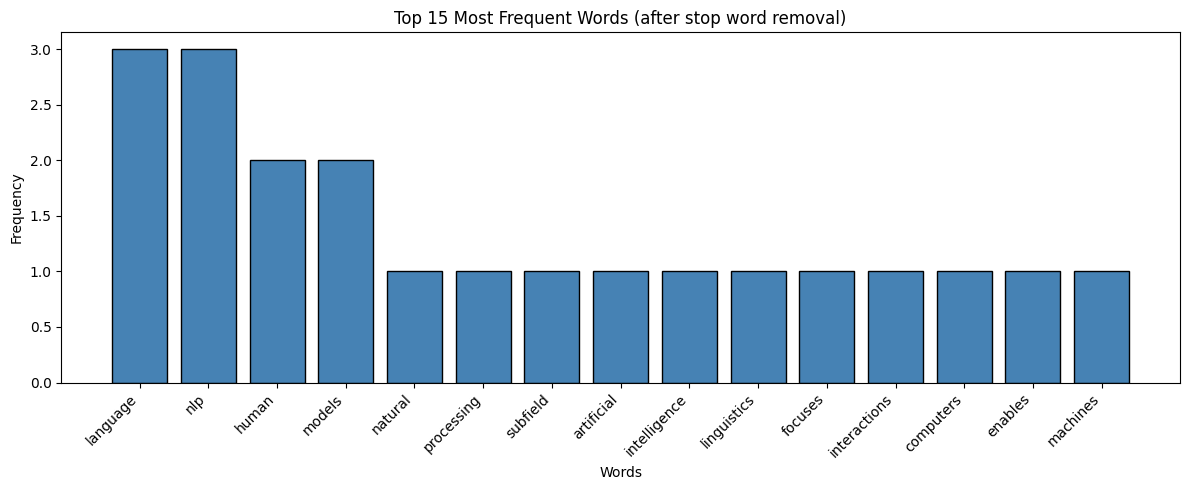

In [12]:
# Plot frequency distribution
plt.figure(figsize=(12, 5))
top_words = fdist.most_common(15)
words_list = [w for w, f in top_words]
freqs     = [f for w, f in top_words]

plt.bar(words_list, freqs, color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 15 Most Frequent Words (after stop word removal)')
plt.tight_layout()
plt.show()

## 10. N-Gram Analysis

In [13]:
def get_top_ngrams(tokens, n, top_k=10):
    """Return the top_k most frequent n-grams from a token list."""
    n_grams = list(ngrams(tokens, n))
    return Counter(n_grams).most_common(top_k)


print("N-GRAM ANALYSIS:")
print("=" * 60)

# Bigrams
print("\nTop 8 Bigrams (2-grams):")
for gram, count in get_top_ngrams(filtered_words, 2, 8):
    print(f"  {' '.join(gram):<35} count: {count}")

# Trigrams
print("\nTop 8 Trigrams (3-grams):")
for gram, count in get_top_ngrams(filtered_words, 3, 8):
    print(f"  {' '.join(gram):<40} count: {count}")

N-GRAM ANALYSIS:

Top 8 Bigrams (2-grams):
  human language                      count: 2
  natural language                    count: 1
  language processing                 count: 1
  processing nlp                      count: 1
  nlp subfield                        count: 1
  subfield artificial                 count: 1
  artificial intelligence             count: 1
  intelligence linguistics            count: 1

Top 8 Trigrams (3-grams):
  natural language processing              count: 1
  language processing nlp                  count: 1
  processing nlp subfield                  count: 1
  nlp subfield artificial                  count: 1
  subfield artificial intelligence         count: 1
  artificial intelligence linguistics      count: 1
  intelligence linguistics focuses         count: 1
  linguistics focuses interactions         count: 1


## 11. Complete Text Preprocessing Pipeline

In [14]:
def full_nlp_pipeline(text):
    """
    Complete NLP preprocessing and analysis pipeline.

    Steps:
      1. Sentence tokenization
      2. Word tokenization
      3. Text cleaning / normalization
      4. Stop word removal
      5. POS tagging
      6. Stemming
      7. Lemmatization
      8. Frequency distribution
    """
    results = {}

    # Step 1: Sentence tokenization
    results['sentences'] = sent_tokenize(text.strip())

    # Step 2: Word tokenization (raw)
    raw_tokens = word_tokenize(text)
    results['raw_tokens'] = raw_tokens

    # Step 3: Normalize
    cleaned = preprocess_text(text)
    tokens = word_tokenize(cleaned)
    results['cleaned_tokens'] = tokens

    # Step 4: Stop word removal
    sw = set(stopwords.words('english'))
    filtered = [w for w in tokens if w not in sw]
    results['filtered_tokens'] = filtered

    # Step 5: POS tagging
    results['pos_tags'] = pos_tag(raw_tokens)

    # Step 6: Stemming
    ps = PorterStemmer()
    results['stemmed'] = [ps.stem(w) for w in filtered]

    # Step 7: Lemmatization
    lm = WordNetLemmatizer()
    results['lemmatized'] = [lm.lemmatize(w, pos='v') for w in filtered]

    # Step 8: Frequency distribution
    results['freq_dist'] = FreqDist(filtered).most_common(10)

    return results


# Test the pipeline
new_text = """
Artificial intelligence is transforming industries across the world.
Healthcare, education, and finance sectors are adopting AI technologies rapidly.
Machine learning algorithms are improving every day with new data.
"""

pipeline_result = full_nlp_pipeline(new_text)

print("COMPLETE NLP PIPELINE RESULT:")
print("=" * 60)
print(f"  Sentences       : {pipeline_result['sentences']}")
print(f"  Raw token count : {len(pipeline_result['raw_tokens'])}")
print(f"  After cleaning  : {len(pipeline_result['cleaned_tokens'])} tokens")
print(f"  After stopwords : {len(pipeline_result['filtered_tokens'])} tokens")
print(f"\n  Sample POS tags : {pipeline_result['pos_tags'][:8]}")
print(f"\n  Stemmed tokens  : {pipeline_result['stemmed'][:10]}")
print(f"  Lemmatized      : {pipeline_result['lemmatized'][:10]}")
print(f"\n  Top 10 words    : {pipeline_result['freq_dist']}")

COMPLETE NLP PIPELINE RESULT:
  Sentences       : ['Artificial intelligence is transforming industries across the world.', 'Healthcare, education, and finance sectors are adopting AI technologies rapidly.', 'Machine learning algorithms are improving every day with new data.']
  Raw token count : 33
  After cleaning  : 28 tokens
  After stopwords : 22 tokens

  Sample POS tags : [('Artificial', 'JJ'), ('intelligence', 'NN'), ('is', 'VBZ'), ('transforming', 'VBG'), ('industries', 'NNS'), ('across', 'IN'), ('the', 'DT'), ('world', 'NN')]

  Stemmed tokens  : ['artifici', 'intellig', 'transform', 'industri', 'across', 'world', 'healthcar', 'educ', 'financ', 'sector']
  Lemmatized      : ['artificial', 'intelligence', 'transform', 'industries', 'across', 'world', 'healthcare', 'education', 'finance', 'sectors']

  Top 10 words    : [('artificial', 1), ('intelligence', 1), ('transforming', 1), ('industries', 1), ('across', 1), ('world', 1), ('healthcare', 1), ('education', 1), ('finance', 1)

## 12. Summary and Conclusion

### What We Accomplished:

1. **Text Preprocessing** - Lowercasing, removing special characters, normalizing whitespace.
2. **Tokenization** - Both sentence-level and word-level tokenization using NLTK.
3. **Stop Word Removal** - Removed common English stop words to retain meaningful tokens.
4. **Stemming** - Reduced words to their root forms using Porter Stemmer.
5. **Lemmatization** - Converted words to their dictionary base forms using WordNetLemmatizer.
6. **POS Tagging** - Labeled each token with its grammatical role (noun, verb, adjective, etc.).
7. **Named Entity Recognition** - Identified organizations, persons, and locations in text.
8. **Frequency Distribution** - Analyzed and visualized the most common words.
9. **N-Gram Analysis** - Extracted bigrams and trigrams to find common word sequences.
10. **Full Pipeline** - Combined all steps into a reusable preprocessing function.

### Key NLTK Components Used:
- `sent_tokenize`, `word_tokenize` - Tokenization
- `stopwords` - Stop word corpus
- `PorterStemmer` - Stemming
- `WordNetLemmatizer` - Lemmatization
- `pos_tag` - Part-of-speech tagging
- `ne_chunk` - Named entity chunking
- `FreqDist` - Frequency distribution
- `ngrams` - N-gram generation